# End-to-End Machine Learning Workflow

## The Complete ML Pipeline
This notebook demonstrates the full ML workflow from raw data to a deployed model:

```
Raw Data
  ↓ Step 0: EDA + Feature Selection
  ↓ Step 1: Extract input (X) and output (y)
  ↓ Step 2: Scale features (StandardScaler)
  ↓ Step 3: Train/Test split
  ↓ Step 4: Train the model
  ↓ Step 5: Evaluate + model selection
  ↓ Step 6: Save with pickle (deployment)
```

## Dataset: Student Placement
- Features: CGPA (academic performance), IQ (intelligence score)
- Target: placement (1 = placed, 0 = not placed)
- Goal: predict whether a student gets placed based on CGPA and IQ


## Step 1: Imports

In [1]:
import numpy as np
import pandas as pd

## Step 2: Load Dataset

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
df = df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


## Step 3: Understand the Pipeline (code comments)

In [9]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

## Step 4: EDA — Visualise Feature Space

In [12]:
import matplotlib.pyplot as plt


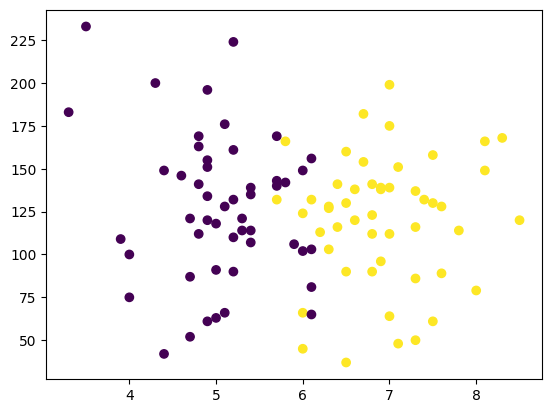

In [16]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

## Step 5: Extract Features (X) and Target (y)

In [17]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [18]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [19]:
y.shape

(100,)

## Step 6: Train/Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [25]:
X_train

,cgpa,iq
14,6.1,103.0
79,6.5,90.0
59,4.8,112.0
29,7.0,112.0
21,7.1,151.0
...,...,...
93,6.8,112.0
15,5.1,176.0
13,6.4,116.0
16,5.2,224.0


In [26]:
y_train

14    0
79    1
59    0
29    1
21    1
     ..
93    1
15    0
13    1
16    0
61    1
Name: placement, Length: 90, dtype: int64

In [27]:
X_test

,cgpa,iq
44,7.5,61.0
71,6.1,132.0
78,6.1,81.0
17,3.3,183.0
91,7.5,158.0
34,4.8,163.0
28,5.2,90.0
51,4.8,141.0
76,4.9,155.0
68,4.0,75.0


## Step 7: Feature Scaling (StandardScaler)

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

In [30]:
X_train = scaler.fit_transform(X_train)

In [31]:
X_train

array([[ 0.04145542, -0.51884336],
       [ 0.40545426, -0.8471542 ],
       [-1.14154079, -0.29155125],
       [ 0.8604528 , -0.29155125],
       [ 0.95145251,  0.69338126],
       [ 2.22544843, -0.08951381],
       [-0.95954137, -1.52903055],
       [-1.05054108, -0.08951381],
       [-0.04954429,  0.01150491],
       [ 1.40645105, -0.87240888],
       [-0.77754195,  0.94592805],
       [ 1.77044989, -1.12495567],
       [-0.32254341,  0.49134382],
       [-0.32254341,  0.21354235],
       [-0.2315437 ,  0.46608914],
       [ 1.13345193, -1.85734138],
       [ 0.13245513, -0.26629657],
       [ 0.40545426,  0.92067337],
       [ 0.49645397,  0.36507042],
       [ 1.40645105,  0.11252363],
       [ 1.8614496 ,  0.6428719 ],
       [ 0.8604528 , -1.50377587],
       [ 0.95145251, -1.90785074],
       [-0.77754195,  0.21354235],
       [ 0.67845338, -0.01374977],
       [ 0.58745367,  0.7691453 ],
       [ 1.13345193, -0.94817291],
       [-1.59653933,  1.93086056],
       [-1.05054108,

In [32]:
X_test = scaler.transform(X_test)

In [33]:
X_test

array([[ 1.31545134, -1.5795399 ],
       [ 0.04145542,  0.21354235],
       [ 0.04145542, -1.07444631],
       [-2.50653642,  1.50153101],
       [ 1.31545134,  0.87016402],
       [-1.14154079,  0.99643741],
       [-0.77754195, -0.8471542 ],
       [-1.14154079,  0.44083446],
       [-1.05054108,  0.79439998],
       [-1.86953846, -1.22597439]])

## Step 8: Train Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
clf = LogisticRegression()

In [36]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 9: Predict and Evaluate

In [37]:
y_pred = clf.predict(X_test)

In [38]:
y_test

44    1
71    1
78    0
17    0
91    1
34    0
28    0
51    0
76    0
68    0
Name: placement, dtype: int64

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_test,y_pred)

0.9

## Step 10: Visualise Decision Boundary

In [42]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

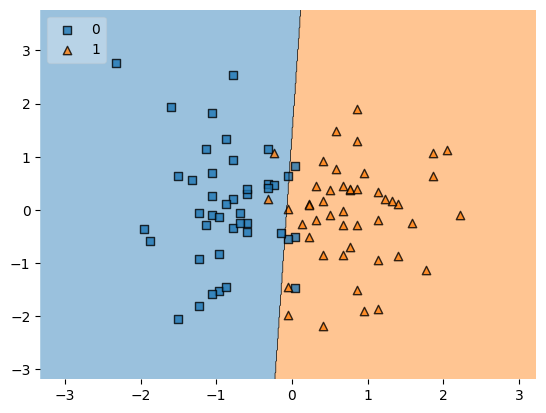

In [47]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

## Step 11: Save Model with Pickle (Deployment)

In [48]:
import pickle

In [49]:
pickle.dump(clf,open('model.pkl','wb'))